In [2]:
# Isotonic calibration
# Install only missing packages
pkgs <- c("tidyverse", "data.table", "nflreadr", "lubridate", "stringr",
      "forcats", "glue", "splines", "splines2", "readr")

installed <- rownames(installed.packages())
to_install <- setdiff(pkgs, installed)

if (length(to_install) > 0) {
  install.packages(to_install)
}

#Load libraries
suppressPackageStartupMessages({
  library(tidyverse)
  library(data.table)
  library(lubridate)
  library(stringr)
  library(forcats)
  library(glue)
  library(splines)
  library(splines2)
  library(readr)
  library(dplyr); library(tidyr); library(purrr); library(readr)
    library(nflreadr)  
    library(rlang)
})

In [3]:
PROJECT_ROOT <- if (requireNamespace("here", quietly = TRUE)) here::here() else getwd()
DATA_DIR <- file.path(PROJECT_ROOT,"Model", "Data")
LEVERAGE_DIR <- file.path(PROJECT_ROOT,"Model", "Leverage")
dir.create(DATA_DIR, recursive = TRUE, showWarnings = FALSE)

SEASONS <- 2000:2024
options(tibble.print_min = 6, tibble.print_max = 6)

print(PROJECT_ROOT)
print(DATA_DIR)
print(LEVERAGE_DIR)


[1] "g:/My files/Python/Sports Analytics Projects/Football/Kickers"
[1] "g:/My files/Python/Sports Analytics Projects/Football/Kickers/Model/Data"
[1] "g:/My files/Python/Sports Analytics Projects/Football/Kickers/Model/Leverage"


In [37]:
# ---- Config ----
eps <- 1e-4

clamp01 <- function(x, eps=1e-4) pmin(pmax(x, eps), 1 - eps)

# Predict-like wrapper for isoreg (step function interpolation)
iso_fit <- function(y_hat, y_true) {
  fit <- stats::isoreg(y_hat, y_true)
  # Convert to a monotone step function over sorted x
  xs <- fit$x
  ys <- fit$yf
  list(xs = xs, ys = ys)
}
iso_predict <- function(fit, x) {
  # Right-continuous step function: find interval in xs
  # approx() with method="constant" and rule=2 (extend) is convenient
  y <- approx(fit$xs, fit$ys, x, method = "constant", ties = "ordered", rule = 2)$y
  clamp01(y, eps = 1e-8)
}

In [ ]:
# Load data
pbp_path <- file.path(DATA_DIR, "pbp_2000_2024_clean.csv")
print(pbp_path)

#Load if file exits, if not return error
if (file.exists(pbp_path)) {
  pbp <- readr::read_csv(pbp_path, guess_max = 10000, show_col_types = FALSE)
} else {
  stop(glue("File {pbp_path} does not exist. Please download the data first."))
}

#readr::write_csv(pbp, sub("\\.csv$", "_clean.csv", pbp_path))

[1] "g:/My files/Python/Sports Analytics Projects/Football/Kickers/Model/Data/pbp_2000_2024_clean.csv"


In [ ]:
#

In [38]:
# ---- 1) Load & prep PBP (2000-2024) ----
# Optional: derive a postseason flag (safe)
pbp <- pbp %>%
  mutate(postseason = if ("season_type" %in% names(pbp)) season_type == "POST" else NA)

# ---- 2) Restrict to kicks (FGs & PATs) and compute wp_post ----
kicks <- pbp %>%
  filter(play_type %in% c("field_goal", "extra_point")) %>%
  transmute(
    game_id, play_id, season, week, qtr,
    postseason,
    is_ot  = qtr >= 5,
    is_pat = (play_type == "extra_point"),
    score_differential = score_differential,
    game_seconds_remaining = game_seconds_remaining,
    yardline_100 = yardline_100,
    kick_distance = kick_distance,
    field_goal_result,
    extra_point_result,
    wp_pre  = wp,
    wpa     = wpa,
    wp_post = clamp01(wp + wpa, eps)
  ) %>%
  filter(!is.na(wp_pre), !is.na(wpa), !is.na(wp_post),
         !is.na(game_seconds_remaining), !is.na(score_differential))

# ---- 3) Build FG-only frame (pool misses + blocks) ----
fg <- kicks %>%
  filter(!is_pat) %>%
  mutate(
    fg_result = dplyr::case_when(
      field_goal_result == "made" ~ "make",
      field_goal_result %in% c("missed", "blocked") ~ "miss",
      TRUE ~ NA_character_
    )
  ) %>%
  filter(!is.na(fg_result))

# Build PAT-only frame (pool misses + blocks)
pats_all <- kicks %>%                      # reuse your 'kicks' frame from earlier
  filter(is_pat) %>%
  transmute(
    game_id, play_id, season, week, qtr, is_ot, is_pat,
    score_differential, game_seconds_remaining,
    wp_pre = wp_pre, wpa = wpa, wp_post = wp_post,
    pat_result = case_when(
      extra_point_result %in% c("made", "good") ~ "make",
      extra_point_result %in% c("missed", "blocked", "failed") ~ "miss",
      TRUE ~ NA_character_
    )
  ) %>% filter(!is.na(pat_result))

# ---- 4) Splits you wanted ----
fg_wpa_train <- fg %>% filter(season >= 2000, season <= 2011)
fg_wpa_test  <- fg %>% filter(season >= 2012, season <= 2014)
fg_valid     <- fg %>% filter(season >= 2015, season <= 2024)

pats_wpa_train <- pats_all %>% filter(season >= 2000, season <= 2011, !is_ot)
pats_wpa_test  <- pats_all %>% filter(season >= 2012, season <= 2014, !is_ot)
pats_valid     <- pats_all %>% filter(season >= 2015, season <= 2024)   # we'll treat OT later

# ---- 5) Persist artifacts for your other notebooks to Data DIR ----
# 1) Save training data (unmodified)
write_csv(fg_wpa_train, file.path(DATA_DIR, "fg_wpa_train_2000_2011.csv"))
write_csv(fg_wpa_test,  file.path(DATA_DIR, "fg_wpa_test_2012_2014.csv"))
write_csv(fg_valid,     file.path(DATA_DIR, "fg_wpa_valid_2015_2024.csv"))
write_csv(pats_wpa_train, file.path(DATA_DIR, "pats_wpa_train_2000_2011.csv"))
write_csv(pats_wpa_test,  file.path(DATA_DIR, "pats_wpa_test_2012_2014.csv"))
write_csv(pats_valid,     file.path(DATA_DIR, "pats_wpa_valid_2015_2024.csv"))

In [42]:
# Feature makers (use in all splits)
mk_feats_make <- function(df) {
  df %>%
    mutate(
      log_time = log1p(game_seconds_remaining),
      t120 = pmax(0, 120 - game_seconds_remaining),
      go_ahead_if_make = as.integer(score_differential + 3 > 0),
      tie_if_make      = as.integer(score_differential + 3 == 0)
    )
}

mk_feats_miss <- function(df) {
  df %>%
    mutate(
      log_time = log1p(game_seconds_remaining),
      t120 = pmax(0, 120 - game_seconds_remaining),
      go_ahead_if_make = as.integer(score_differential + 3 > 0),
      tie_if_make      = as.integer(score_differential + 3 == 0),
    )
}

make_train2 <- mk_feats_make(fg_wpa_train %>% filter(fg_result=="make", !is_ot))
miss_train2 <- mk_feats_miss(fg_wpa_train %>% filter(fg_result=="miss", !is_ot, !is.na(yardline_100)))

head(make_train2)

game_id,play_id,season,week,qtr,postseason,is_ot,is_pat,score_differential,game_seconds_remaining,⋯,field_goal_result,extra_point_result,wp_pre,wpa,wp_post,fg_result,log_time,t120,go_ahead_if_make,tie_if_make
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<lgl>,<lgl>,<dbl>,<dbl>,⋯,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<int>,<int>
2000_01_ARI_NYG,2771,2000,1,3,FALSE,FALSE,FALSE,-14,905,⋯,made,NA,0.09023836,-0.016740225,0.07349813,make,6.809039,0,0,0
2000_01_BAL_PIT,467,2000,1,1,FALSE,FALSE,FALSE,0,3201,⋯,made,NA,0.58615232,-0.012400478,0.57375184,make,8.071531,0,1,0
2000_01_BAL_PIT,1810,2000,1,2,FALSE,FALSE,FALSE,10,1811,⋯,made,NA,0.85888731,0.040558338,0.89944565,make,7.502186,0,1,0
2000_01_BAL_PIT,2027,2000,1,3,FALSE,FALSE,FALSE,13,1800,⋯,made,NA,0.91332519,-0.000562720,0.91276247,make,7.496097,0,1,0
2000_01_CAR_WAS,646,2000,1,1,FALSE,FALSE,FALSE,0,3008,⋯,made,NA,0.58129638,-0.008751661,0.57254472,make,8.009363,0,1,0
2000_01_CAR_WAS,2483,2000,1,3,FALSE,FALSE,FALSE,-3,1602,⋯,made,NA,0.52555656,0.024753720,0.55031028,make,7.379632,0,0,1


In [43]:
fam <- quasibinomial(link="logit")

# ---- 3) Fit heads (fractional logit GLMs) ----
mod_make <- glm(
wp_post ~ log_time + score_differential
        + go_ahead_if_make + tie_if_make
        + log_time:score_differential
        + t120:go_ahead_if_make + t120:tie_if_make,
  data = make_train2, family = fam
)

mod_miss <- glm(
wp_post ~ log_time + score_differential + yardline_100
        + go_ahead_if_make + tie_if_make
        + log_time:score_differential
        + t120:go_ahead_if_make + t120:tie_if_make,
  data = miss_train2, family = fam
)

summary(mod_make)
summary(mod_miss)


Call:
glm(formula = wp_post ~ log_time + score_differential + go_ahead_if_make + 
    tie_if_make + log_time:score_differential + t120:go_ahead_if_make + 
    t120:tie_if_make, family = fam, data = make_train2)

Coefficients:
                              Estimate Std. Error t value Pr(>|t|)    
(Intercept)                  1.4480184  0.0403824  35.858  < 2e-16 ***
log_time                    -0.1506751  0.0053724 -28.046  < 2e-16 ***
score_differential           0.7011220  0.0076519  91.627  < 2e-16 ***
go_ahead_if_make             0.1013983  0.0133615   7.589 3.53e-14 ***
tie_if_make                  0.1104200  0.0137400   8.036 1.04e-15 ***
log_time:score_differential -0.0733946  0.0010349 -70.919  < 2e-16 ***
go_ahead_if_make:t120        0.0132207  0.0004384  30.160  < 2e-16 ***
tie_if_make:t120             0.0014959  0.0004359   3.432 0.000602 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for quasibinomial family taken to be 0.01957


Call:
glm(formula = wp_post ~ log_time + score_differential + yardline_100 + 
    go_ahead_if_make + tie_if_make + log_time:score_differential + 
    t120:go_ahead_if_make + t120:tie_if_make, family = fam, data = miss_train2)

Coefficients:
                              Estimate Std. Error t value Pr(>|t|)    
(Intercept)                 -0.6975051  0.0864684  -8.067 1.17e-15 ***
log_time                     0.0907691  0.0109668   8.277  < 2e-16 ***
score_differential           0.7578721  0.0156749  48.349  < 2e-16 ***
yardline_100                -0.0059058  0.0008615  -6.855 9.17e-12 ***
go_ahead_if_make            -0.0224187  0.0269058  -0.833 0.404805    
tie_if_make                 -0.1059213  0.0302376  -3.503 0.000469 ***
log_time:score_differential -0.0803991  0.0021231 -37.869  < 2e-16 ***
go_ahead_if_make:t120        0.0021158  0.0006618   3.197 0.001408 ** 
tie_if_make:t120            -0.0096182  0.0015091  -6.374 2.24e-10 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 

In [44]:
# ---- Robust metrics for fractional-logit (quasi-binomial) ----
fraclogit_metrics <- function(model, data, yvar = "wp_post", bins = 10, eps = 1e-6) {
  stopifnot(yvar %in% names(data))
  y <- data[[yvar]]
  ph <- as.numeric(predict(model, newdata = data, type = "response"))
  # Clamp only for stability
  ph <- pmin(pmax(ph, eps), 1 - eps)

  # Basic stats
  ybar <- mean(y, na.rm = TRUE)
  rss  <- sum((y - ph)^2, na.rm = TRUE)
  tss  <- sum((y - ybar)^2, na.rm = TRUE)
  r2_efron <- 1 - rss / tss

  # Deviance "R^2": guard against null deviance = 0
  dev_res  <- tryCatch(deviance(model), error = function(e) NA_real_)
  null_mod <- tryCatch(update(model, formula = as.formula(paste(yvar, "~ 1"))), error = function(e) NULL)
  dev_null <- if (!is.null(null_mod)) tryCatch(deviance(null_mod), error = function(e) NA_real_) else NA_real_
  r2_deviance <- if (is.finite(dev_res) && is.finite(dev_null) && dev_null > 0) 1 - (dev_res / dev_null) else NA_real_

  # Proper scoring
  brier <- mean((y - ph)^2, na.rm = TRUE)
  mae   <- mean(abs(y - ph), na.rm = TRUE)
  rmse  <- sqrt(mean((y - ph)^2, na.rm = TRUE))

  # Calibration by bins (robust to ties via ntile)
  df <- data.frame(y = y, ph = ph)
  df <- df[is.finite(df$y) & is.finite(df$ph), , drop = FALSE]
  # If too few unique ph, reduce bins gracefully
  uniq_ph <- length(unique(df$ph))
  k <- max(2L, min(bins, uniq_ph))
  df$bin <- dplyr::ntile(df$ph, k)

  cal <- df |>
    dplyr::group_by(bin) |>
    dplyr::summarise(y = mean(y), ph = mean(ph), .groups = "drop")

  cal_rmse <- sqrt(mean((cal$y - cal$ph)^2))

  list(
    r2_efron = r2_efron,
    r2_deviance = r2_deviance,
    brier = brier,
    mae = mae,
    rmse = rmse,
    calibration_rmse = cal_rmse,
    calibration_table = cal,
    n_bins = k
  )
}

# ---- Simple calibration plot (deciles or k bins used above) ----
plot_cal <- function(cal_tbl, main = "Calibration (bins)") {
  with(cal_tbl, {
    plot(ph, y, xlab = "Predicted", ylab = "Observed", main = main, pch = 19)
    abline(0, 1, lty = 2)
  })
}

# ---------- Core probability metrics given y and ph (test-safe) ----------
prob_metrics <- function(y, ph, bins = 10, eps = 1e-6) {
  # clamp for numerical stability only
  ph <- pmin(pmax(ph, eps), 1 - eps)

  # Efron's R^2 (variance explained)
  ybar <- mean(y, na.rm = TRUE)
  rss  <- sum((y - ph)^2, na.rm = TRUE)
  tss  <- sum((y - ybar)^2, na.rm = TRUE)
  r2_efron <- 1 - rss / tss

  # Proper scoring
  brier <- mean((y - ph)^2, na.rm = TRUE)
  mae   <- mean(abs(y - ph),  na.rm = TRUE)
  rmse  <- sqrt(mean((y - ph)^2, na.rm = TRUE))

  # Robust calibration bins (handles ties)
  df <- data.frame(y = y, ph = ph)
  df <- df[is.finite(df$y) & is.finite(df$ph), , drop = FALSE]
  k  <- max(2L, min(bins, length(unique(df$ph))))
  df$bin <- dplyr::ntile(df$ph, k)

  cal <- df |>
    dplyr::group_by(bin) |>
    dplyr::summarise(y = mean(y), ph = mean(ph), .groups = "drop")
  cal_rmse <- sqrt(mean((cal$y - cal$ph)^2))

  list(
    r2_efron = r2_efron,
    brier = brier,
    mae = mae,
    rmse = rmse,
    calibration_rmse = cal_rmse,
    calibration_table = cal,
    n_bins = k
  )
}

# ---------- Test-set evaluator for quasi-binomial models ----------
score_metrics <- function(model, df, yvar = "wp_post", label = "", bins = 10, eps = 1e-6) {
  stopifnot(yvar %in% names(df))
  y  <- df[[yvar]]
  ph <- as.numeric(predict(model, newdata = df, type = "response"))
  m  <- prob_metrics(y, ph, bins = bins, eps = eps)

  cat(sprintf("[%s] R2_Efron=%.3f  Brier=%.5f  MAE=%.4f  CalRMSE=%.4f  (bins=%d)\n",
              label, m$r2_efron, m$brier, m$mae, m$calibration_rmse, m$n_bins))
  invisible(m)
}

# ---------- Optional: quick summary of prediction distribution ----------
summarize_preds <- function(model, df) {
  ph <- as.numeric(predict(model, newdata = df, type = "response"))
  print(summary(ph))
  invisible(ph)
}


=== In-sample (train) summary ===
# A tibble: 2 × 8
  model        r2_efron r2_deviance   brier    mae   rmse cal_rmse n_bins
  <chr>           <dbl>       <dbl>   <dbl>  <dbl>  <dbl>    <dbl>  <dbl>
1 Make — train    0.97        0.966 0.00220 0.0334 0.0469  0.00421     10
2 Miss — train    0.954       0.949 0.00364 0.0409 0.0604  0.00833     10

=== Calibration tables (per-bin) ===
-- Make head (bins = 10 ) --
# A tibble: 10 × 3
    bin      y    ph
  <dbl>  <dbl> <dbl>
1     1 0.0989 0.101
2     2 0.290  0.280
3     3 0.405  0.411
4     4 0.531  0.534
5     5 0.586  0.585
6     6 0.625  0.624
# ℹ 4 more rows
-- Miss head (bins = 10 ) --
# A tibble: 10 × 3
    bin      y     ph
  <dbl>  <dbl>  <dbl>
1     1 0.0396 0.0392
2     2 0.145  0.142 
3     3 0.237  0.253 
4     4 0.330  0.335 
5     5 0.446  0.429 
6     6 0.462  0.463 
# ℹ 4 more rows


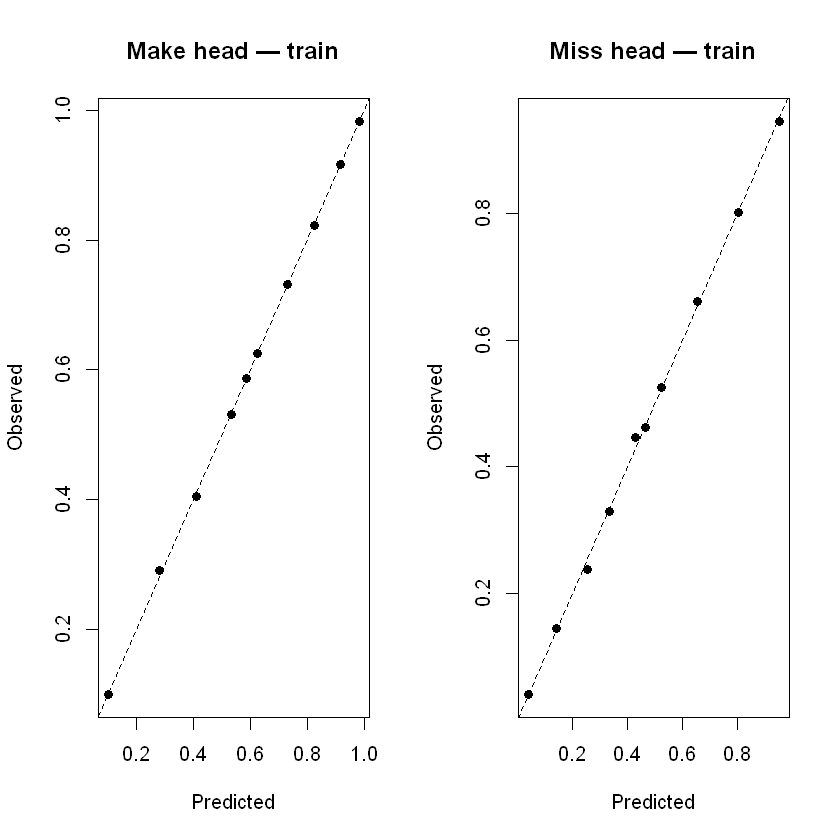

In [45]:
# ==== CELL 1: In-sample results (train) + prettier calibration output ====

# assumes: mod_make, mod_miss, make_train2, miss_train2 already exist
stats_make_tr <- fraclogit_metrics(mod_make, make_train2, "wp_post")
stats_miss_tr <- fraclogit_metrics(mod_miss, miss_train2, "wp_post")

# Compact summary table
summary_tbl <- dplyr::bind_rows(
    tibble::tibble(
        model = "Make — train",
        r2_efron = round(stats_make_tr$r2_efron, 3),
        r2_deviance = ifelse(is.na(stats_make_tr$r2_deviance), NA, round(stats_make_tr$r2_deviance, 3)),
        brier = signif(stats_make_tr$brier, 5),
        mae = signif(stats_make_tr$mae, 4),
        rmse = signif(stats_make_tr$rmse, 4),
        cal_rmse = signif(stats_make_tr$calibration_rmse, 4),
        n_bins = stats_make_tr$n_bins
    ),
    tibble::tibble(
        model = "Miss — train",
        r2_efron = round(stats_miss_tr$r2_efron, 3),
        r2_deviance = ifelse(is.na(stats_miss_tr$r2_deviance), NA, round(stats_miss_tr$r2_deviance, 3)),
        brier = signif(stats_miss_tr$brier, 5),
        mae = signif(stats_miss_tr$mae, 4),
        rmse = signif(stats_miss_tr$rmse, 4),
        cal_rmse = signif(stats_miss_tr$calibration_rmse, 4),
        n_bins = stats_miss_tr$n_bins
    )
)

cat("=== In-sample (train) summary ===\n")
print(summary_tbl)

# Pretty-print per-bin calibration tables (rounded)
cat("\n=== Calibration tables (per-bin) ===\n")
cat("-- Make head (bins =", stats_make_tr$n_bins, ") --\n")
print(stats_make_tr$calibration_table %>% dplyr::mutate(across(everything(), ~ round(.x, 4))))
cat("-- Miss head (bins =", stats_miss_tr$n_bins, ") --\n")
print(stats_miss_tr$calibration_table %>% dplyr::mutate(across(everything(), ~ round(.x, 4))))

# Calibration plots side-by-side
par(mfrow = c(1, 2))
plot_cal(stats_make_tr$calibration_table, "Make head — train")
plot_cal(stats_miss_tr$calibration_table, "Miss head — train")
par(mfrow = c(1, 1))



=== Test-set summary ===
# A tibble: 2 × 8
  model       r2_efron r2_deviance   brier    mae   rmse cal_rmse n_bins
  <chr>          <dbl>       <dbl>   <dbl>  <dbl>  <dbl>    <dbl>  <dbl>
1 Make — test    0.957       0.966 0.00337 0.0357 0.0581  0.00938     10
2 Miss — test    0.951       0.949 0.00381 0.043  0.0618  0.0167      10

=== Calibration tables (per-bin) ===
-- Make head --
# A tibble: 10 × 3
    bin      y    ph
  <int>  <dbl> <dbl>
1     1 0.0995 0.101
2     2 0.277  0.270
3     3 0.393  0.397
4     4 0.523  0.530
5     5 0.583  0.585
6     6 0.659  0.632
# ℹ 4 more rows
-- Miss head --
# A tibble: 10 × 3
    bin      y     ph
  <int>  <dbl>  <dbl>
1     1 0.0441 0.0491
2     2 0.166  0.180 
3     3 0.254  0.267 
4     4 0.365  0.341 
5     5 0.473  0.434 
6     6 0.451  0.467 
# ℹ 4 more rows

Make preds summary:
     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
2.518e-05 3.900e-01 5.935e-01 5.986e-01 8.311e-01 1.000e+00 

Miss preds summary:
     Min.   1st Q

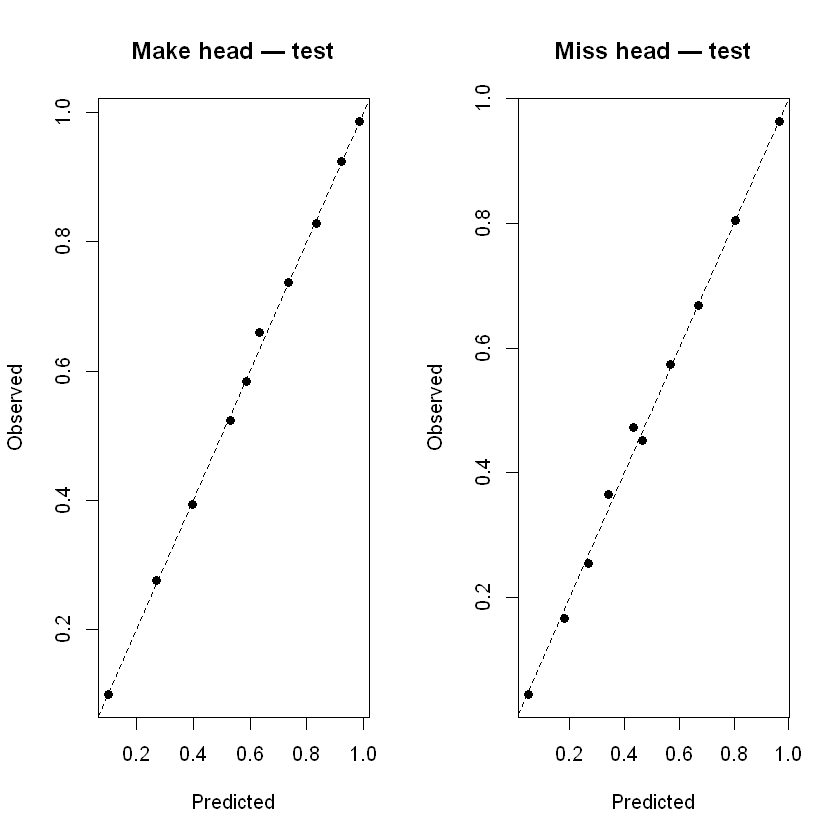

In [46]:
# ==== CELL 2: Test predictions (2012–2014) + prettier scores + calibration plots ====

# ensure test frames include engineered features required by the models
make_test  <- dplyr::filter(fg_wpa_test,  fg_result == "make")
miss_test  <- dplyr::filter(fg_wpa_test,  fg_result == "miss", !is.na(yardline_100))
make_test2 <- mk_feats_make(make_test)
miss_test2 <- mk_feats_miss(miss_test)

# compute metrics (use fraclogit_metrics directly for structured output)
m_test  <- fraclogit_metrics(mod_make, make_test2, "wp_post")
ms_test <- fraclogit_metrics(mod_miss, miss_test2, "wp_post")

# pretty summary table (rounded / signif for compact display)
summary_tbl <- dplyr::bind_rows(
    tibble::tibble(
        model = "Make — test",
        r2_efron = round(m_test$r2_efron, 3),
        r2_deviance = ifelse(is.na(m_test$r2_deviance), NA, round(m_test$r2_deviance, 3)),
        brier = signif(m_test$brier, 5),
        mae = signif(m_test$mae, 4),
        rmse = signif(m_test$rmse, 4),
        cal_rmse = signif(m_test$calibration_rmse, 4),
        n_bins = m_test$n_bins
    ),
    tibble::tibble(
        model = "Miss — test",
        r2_efron = round(ms_test$r2_efron, 3),
        r2_deviance = ifelse(is.na(ms_test$r2_deviance), NA, round(ms_test$r2_deviance, 3)),
        brier = signif(ms_test$brier, 5),
        mae = signif(ms_test$mae, 4),
        rmse = signif(ms_test$rmse, 4),
        cal_rmse = signif(ms_test$calibration_rmse, 4),
        n_bins = ms_test$n_bins
    )
)

cat("=== Test-set summary ===\n")
print(summary_tbl)

cat("\n=== Calibration tables (per-bin) ===\n")
cat("-- Make head --\n"); print(m_test$calibration_table)
cat("-- Miss head --\n"); print(ms_test$calibration_table)

# plots
par(mfrow = c(1, 2))
plot_cal(m_test$calibration_table,  "Make head — test")
plot_cal(ms_test$calibration_table, "Miss head — test")
par(mfrow = c(1, 1))

# (optional) quick distribution summaries of test predictions
cat("\nMake preds summary:\n"); summarize_preds(mod_make, make_test2)
cat("\nMiss preds summary:\n"); summarize_preds(mod_miss, miss_test2)



=== TEST (outcome-conditional) overall ===
R2_Efron: 0.973 -> 0.974 | Brier: 0.00215 -> 0.00206 | CalRMSE: 0.0034 -> 0.0038

=== TEST (outcome-conditional) by outcome ===
Make  — R2: 0.975->0.976  Brier: 0.00194->0.00188  CalRMSE: 0.0046->0.0048
Miss  — R2: 0.958->0.961  Brier: 0.00334->0.00310  CalRMSE: 0.0122->0.0111

=== TEST (outcome-conditional) late & close ===
R2_Efron: 0.909->0.931  Brier: 0.00854->0.00641  CalRMSE: 0.0495->0.0513


season,week,game_id,qtr,game_seconds_remaining,score_differential,yardline_100,kick_distance,fg_result,wp_post,wp_make_hat,wp_miss_hat,pred_hat_pre,wp_make_hat_rules,wp_miss_hat_rules,pred_hat_post,leverage,leverage_rules
<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2013,2,2013_02_TEN_HOU,4,0,0,28,46,miss,0.5704801,0.9583495,0.34719559,0.3471956,0.9950000,0.34719559,0.3471956,0.6111540,0.6478044
2013,14,2013_14_CLE_NE,4,1,-1,40,58,miss,0.0001000,0.9143537,0.20691835,0.2069184,0.9950000,0.00500000,0.0050000,0.7074353,0.9900000
2014,11,2014_11_ATL_CAR,4,1,-2,45,63,miss,0.0001000,0.8478378,0.11152333,0.1115233,0.9950000,0.00500000,0.0050000,0.7363145,0.9900000
2014,15,2014_15_MIN_DET,4,1,-2,50,68,miss,0.0001000,0.8478378,0.10863082,0.1086308,0.9950000,0.00500000,0.0050000,0.7392070,0.9900000
2012,3,2012_03_NE_BAL,4,2,-2,9,27,make,0.9999000,0.8459191,0.14644249,0.8459191,0.9950000,0.00500000,0.9950000,0.6994766,0.9900000
2012,6,2012_06_BUF_ARI,4,2,0,20,38,miss,0.4766033,0.9499756,0.38021058,0.3802106,0.9950000,0.38021058,0.3802106,0.5697650,0.6147894
2012,10,2012_10_KC_PIT,4,2,-3,28,46,make,0.4523059,0.4275036,0.01776416,0.4275036,0.4275036,0.01776416,0.4275036,0.4097394,0.4097394
2012,13,2012_13_SF_STL,4,2,-3,35,53,make,0.5719110,0.4275036,0.01705703,0.4275036,0.4275036,0.01705703,0.4275036,0.4104465,0.4104465
2013,5,2013_05_DEN_DAL,4,2,0,10,28,make,0.9999000,0.9499756,0.39422266,0.9499756,0.9950000,0.39422266,0.9950000,0.5557529,0.6007773


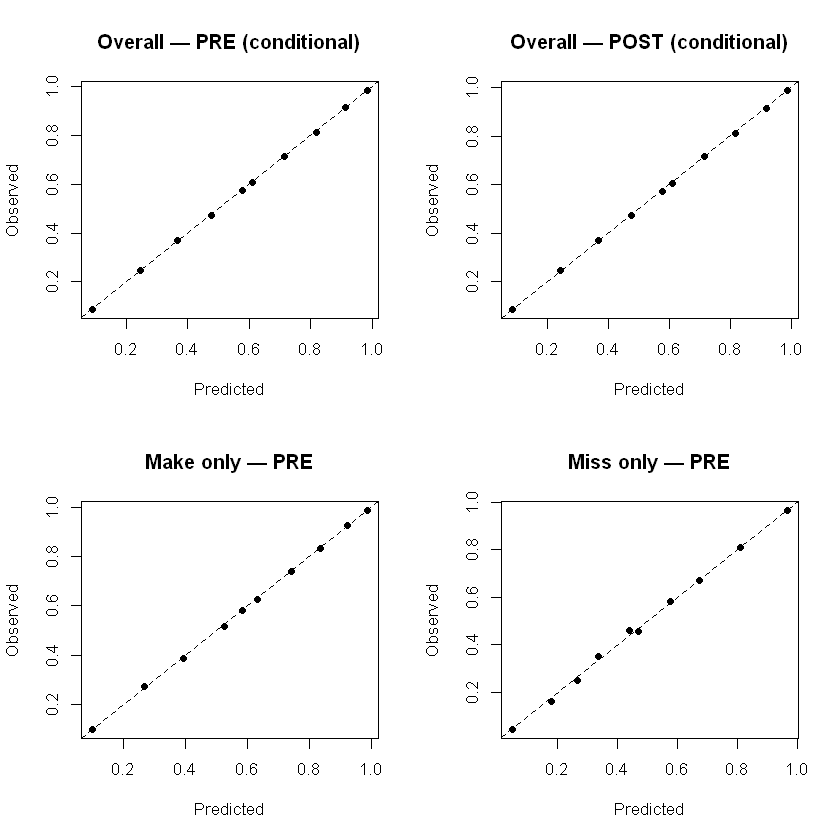

In [56]:
# ==== Outcome-conditional TEST evaluation (pre vs post rules) ====

# ---- Rule layer (preserves originals, returns *_rules columns) ----
apply_endgame_rules <- function(df, eps = 1e-6) {
  clamp01 <- function(x) pmin(pmax(x, eps), 1 - eps)

  # flags
  go_ahead_if_make <- df$score_differential + 3 > 0
  tie_if_make      <- df$score_differential + 3 == 0
  trailing_on_miss <- df$score_differential < 0
  is_q4_nonot      <- df$qtr == 4 & !df$is_ot

  # time buckets
  t0 <- is_q4_nonot & df$game_seconds_remaining <= 5
  t1 <- is_q4_nonot & df$game_seconds_remaining >= 6 & df$game_seconds_remaining <= 10

  # start from originals
  make2 <- df$wp_make_hat
  miss2 <- df$wp_miss_hat

  # ---- T0: ≤5s (hard push, only if not already extreme) ----
  idx <- t0 & go_ahead_if_make & (make2 < 0.98)
  make2[idx] <- 0.995

  idx <- t0 & (go_ahead_if_make | tie_if_make) & trailing_on_miss & (miss2 > 0.02)
  miss2[idx] <- 0.005

  # ---- T1: 6–10s (light nudge, only if not already near-extreme) ----
  idx <- t1 & go_ahead_if_make & (make2 < 0.95)
  make2[idx] <- 0.95

  idx <- t1 & (go_ahead_if_make | tie_if_make) & trailing_on_miss & (miss2 > 0.05)
  miss2[idx] <- 0.05

  dplyr::mutate(
    df,
    wp_make_hat_rules = clamp01(make2),
    wp_miss_hat_rules = clamp01(miss2),
    leverage_rules    = pmin(pmax(wp_make_hat_rules - wp_miss_hat_rules, 0), 1)
  )
}
# 1) Build common TEST frame (non-OT, yardline available)
test_base <- fg_wpa_test %>%
  dplyr::filter(!is_ot, !is.na(yardline_100)) %>%
  dplyr::select(game_id, play_id, season, week, qtr, is_ot, is_pat,
                score_differential, game_seconds_remaining,
                yardline_100, kick_distance, field_goal_result,
                wp_pre, wpa, wp_post, fg_result)

# 2) Score both heads (keep originals)
eps <- 1e-6; clamp01 <- function(x) pmin(pmax(x, eps), 1 - eps)
test_scored <- test_base %>%
  dplyr::mutate(
    wp_make_hat = clamp01(predict(mod_make, newdata = mk_feats_make(test_base), type = "response")),
    wp_miss_hat = clamp01(predict(mod_miss, newdata = mk_feats_miss(test_base), type = "response")),
    leverage    = pmin(pmax(wp_make_hat - wp_miss_hat, 0), 1)
  )

# 3) Apply minimal rules -> *_rules columns
test_scored_rules <- apply_endgame_rules(test_scored)

# 4) Late & close subset (for reporting only)
late_close <- test_scored_rules %>%
  dplyr::filter(qtr == 4, abs(score_differential) <= 3, game_seconds_remaining <= 120)

# 1) Add outcome-conditional predictions
add_conditional_preds <- function(df) {
  is_make <- df$fg_result == "make"
  is_miss <- df$fg_result == "miss"  # includes blocked if you mapped to "miss"

  df$pred_hat_pre  <- ifelse(is_make, df$wp_make_hat,  df$wp_miss_hat)
  df$pred_hat_post <- ifelse(is_make, df$wp_make_hat_rules %||% df$wp_make_hat,
                                      df$wp_miss_hat_rules %||% df$wp_miss_hat)
  df
}

`%||%` <- function(a, b) if (!is.null(a)) a else b

test_cond <- test_scored_rules |> add_conditional_preds()

# 2) Overall outcome-conditional metrics (entire test)
overall_pre  <- prob_metrics(test_cond$wp_post, test_cond$pred_hat_pre)
overall_post <- prob_metrics(test_cond$wp_post, test_cond$pred_hat_post)

cat("\n=== TEST (outcome-conditional) overall ===\n")
cat(sprintf("R2_Efron: %.3f -> %.3f | Brier: %.5f -> %.5f | CalRMSE: %.4f -> %.4f\n",
            overall_pre$r2_efron, overall_post$r2_efron,
            overall_pre$brier,    overall_post$brier,
            overall_pre$calibration_rmse, overall_post$calibration_rmse))

# 3) By outcome (make vs miss)
make_rows <- test_cond |> dplyr::filter(fg_result == "make")
miss_rows <- test_cond |> dplyr::filter(fg_result == "miss")

make_pre  <- prob_metrics(make_rows$wp_post, make_rows$pred_hat_pre)
make_post <- prob_metrics(make_rows$wp_post, make_rows$pred_hat_post)

miss_pre  <- prob_metrics(miss_rows$wp_post, miss_rows$pred_hat_pre)
miss_post <- prob_metrics(miss_rows$wp_post, miss_rows$pred_hat_post)

cat("\n=== TEST (outcome-conditional) by outcome ===\n")
cat(sprintf("Make  — R2: %.3f->%.3f  Brier: %.5f->%.5f  CalRMSE: %.4f->%.4f\n",
            make_pre$r2_efron, make_post$r2_efron,
            make_pre$brier,    make_post$brier,
            make_pre$calibration_rmse, make_post$calibration_rmse))
cat(sprintf("Miss  — R2: %.3f->%.3f  Brier: %.5f->%.5f  CalRMSE: %.4f->%.4f\n",
            miss_pre$r2_efron, miss_post$r2_efron,
            miss_pre$brier,    miss_post$brier,
            miss_pre$calibration_rmse, miss_post$calibration_rmse))

# 4) Late & close subset (Q4, +/-3, <=120s), outcome-conditional
late_close <- test_cond |>
  dplyr::filter(qtr == 4, abs(score_differential) <= 3, game_seconds_remaining <= 120)

lc_pre  <- prob_metrics(late_close$wp_post, late_close$pred_hat_pre)
lc_post <- prob_metrics(late_close$wp_post, late_close$pred_hat_post)

cat("\n=== TEST (outcome-conditional) late & close ===\n")
cat(sprintf("R2_Efron: %.3f->%.3f  Brier: %.5f->%.5f  CalRMSE: %.4f->%.4f\n",
            lc_pre$r2_efron, lc_post$r2_efron,
            lc_pre$brier,    lc_post$brier,
            lc_pre$calibration_rmse, lc_post$calibration_rmse))

# 5) Quick top edge cases (after rules) for eyeballing
late_close |>
  dplyr::arrange((game_seconds_remaining)) |>
  dplyr::select(season, week, game_id, qtr, game_seconds_remaining,
                score_differential, yardline_100, kick_distance, fg_result,
                wp_post, wp_make_hat, wp_miss_hat, pred_hat_pre,
                wp_make_hat_rules, wp_miss_hat_rules, pred_hat_post,
                leverage, leverage_rules) |>
  tibble::as_tibble() |>
  head(10)

# 6) Optional calibration plots (outcome-conditional)
par(mfrow = c(2, 2))
plot_cal(overall_pre$calibration_table,  "Overall — PRE (conditional)")
plot_cal(overall_post$calibration_table, "Overall — POST (conditional)")
plot_cal(make_pre$calibration_table,     "Make only — PRE")
plot_cal(miss_pre$calibration_table,     "Miss only — PRE")
par(mfrow = c(1, 1))


In [57]:
test_cond |>
  dplyr::filter(!is_ot) |>
  dplyr::group_by(qtr) |>
  dplyr::summarise(n=dplyr::n(),
                   mean_lev=mean(leverage, na.rm=TRUE),
                   p90_lev=quantile(leverage, 0.90, na.rm=TRUE),
                   .groups="drop")

qtr,n,mean_lev,p90_lev
<dbl>,<int>,<dbl>,<dbl>
1,590,0.10190116,0.1280090
2,1088,0.09505314,0.1428257
3,573,0.09239423,0.1666232
4,815,0.15166282,0.4130462


In [58]:
# ==== VALIDATION (2015–2024): score -> apply rules -> set OT constant -> export ====

# Assumes you already have:
# - fg_valid (2015–2024)
# - mod_make, mod_miss
# - mk_feats_make(df), mk_feats_miss(df)
# - apply_endgame_rules_min(df)  # from earlier message
# - prob_metrics(), clamp01()

eps <- 1e-6
clamp01 <- function(x) pmin(pmax(x, eps), 1 - eps)

# Save models + rule function for reproducibility to Leverage DIR
saveRDS(list(
  mod_make = mod_make,
  mod_miss = mod_miss,
  mk_feats_make = mk_feats_make,
  mk_feats_miss = mk_feats_miss,
  apply_endgame_rules = apply_endgame_rules
), file.path(LEVERAGE_DIR, "wp_heads_rulepack.rds"))

# 1) Build base validation frame (keep raw columns only)
valid_base <- fg_valid %>%
  dplyr::select(game_id, play_id, season, week, qtr, is_ot, is_pat,
                score_differential, game_seconds_remaining,
                yardline_100, kick_distance, field_goal_result,
                wp_pre, wpa, wp_post, fg_result)

# 2) Non-OT rows with required fields (same rows for both heads)
valid_nonot <- valid_base %>%
  dplyr::filter(!is_ot, !is.na(yardline_100))

# 3) Apply feature engineering BEFORE prediction (per head)
valid_make2 <- mk_feats_make(valid_nonot)
valid_miss2 <- mk_feats_miss(valid_nonot)

# 4) Predict post-WP heads
valid_scored <- valid_nonot %>%
  dplyr::mutate(
    wp_make_hat = clamp01(predict(mod_make, newdata = valid_make2, type = "response")),
    wp_miss_hat = clamp01(predict(mod_miss, newdata = valid_miss2, type = "response")),
    leverage    = pmin(pmax(wp_make_hat - wp_miss_hat, 0), 1)
  )

# 5) Apply minimal endgame rules (adds *_rules & leverage_rules; preserves originals)
valid_scored_rules <- apply_endgame_rules(valid_scored)

# 6) Derive an OT constant from REGULATION situations that resemble OT pressure:

#Rules, q4, not ot, 0-120s, score diff = -3,-2,-1,0
lc_mid <- valid_scored_rules %>%
  dplyr::filter(qtr == 4, !is_ot, score_differential >= -3, score_differential <= 0,
                game_seconds_remaining <= 120,
                game_seconds_remaining >= 0)

#Get 75th percentile of leverage_rules
ot_leverage_constant <- quantile(lc_mid$leverage_rules, 0.5, na.rm = TRUE)

message(sprintf("OT leverage constant (validation, tying & 0–120s): %.4f", ot_leverage_constant))

# 7) Compose OT rows using the constant
valid_ot <- valid_base %>%
  dplyr::filter(is_ot) %>%
  dplyr::transmute(
    game_id, play_id, season, week, qtr, is_ot, is_pat,
    score_differential, game_seconds_remaining, yardline_100, kick_distance,
    field_goal_result, wp_pre, wpa, wp_post, fg_result,
    wp_make_hat = NA_real_, wp_miss_hat = NA_real_, leverage = NA_real_,
    wp_make_hat_rules = NA_real_, wp_miss_hat_rules = NA_real_,
    leverage_rules = ot_leverage_constant
  )

# 8) Final validation set
fg_valid_final <- dplyr::bind_rows(valid_scored_rules, valid_ot)

# 9) Quick sanity
fg_valid_final %>%
  dplyr::summarise(
    n = dplyr::n(),
    n_ot = sum(is_ot),
    n_nonot = sum(!is_ot),
    n_miss = sum(fg_result == "miss", na.rm = TRUE),
    n_make = sum(fg_result == "make", na.rm = TRUE),
    n_na_lev = sum(is.na(leverage_rules)),
    min_lev = min(leverage_rules, na.rm = TRUE),
    max_lev = max(leverage_rules, na.rm = TRUE),
    q1_lev  = quantile(leverage_rules, 0.10, na.rm = TRUE),
    median_lev = median(leverage_rules, na.rm = TRUE),
    q3_lev  = quantile(leverage_rules, 0.75, na.rm = TRUE),
    mean_lev = mean(leverage_rules, na.rm = TRUE),
    p90_lev  = quantile(leverage_rules, 0.90, na.rm = TRUE),
    p95_lev  = quantile(leverage_rules, 0.95, na.rm = TRUE)
  )

# 10) Save to Leverage DIR
readr::write_csv(fg_valid_final, file.path(LEVERAGE_DIR, "fg_valid_with_leverage_rules_2015_2024.csv"))

OT leverage constant (validation, tying & 0–120s): 0.5342



n,n_ot,n_nonot,n_miss,n_make,n_na_lev,min_lev,max_lev,q1_lev,median_lev,q3_lev,mean_lev,p90_lev,p95_lev
<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
10624,138,10486,1638,8986,0,0,0.99,0.02615294,0.1017549,0.1360948,0.1234517,0.1923313,0.3281731


In [63]:
# =======================
# PAT leverage pipeline
# =======================

library(dplyr)

# --- 0) Helper feature makers for PATs ---
mk_feats_pat_make <- function(df) {
  df %>%
    mutate(
      log_time = log1p(game_seconds_remaining),
      go_ahead_if_make = as.integer(score_differential + 1 == 1),
      tie_if_make      = as.integer(score_differential + 1 == 0),
      trailing_on_miss = as.integer(score_differential < 0)
    )
}

mk_feats_pat_miss <- function(df) {
  df %>%
    mutate(
      log_time = log1p(game_seconds_remaining),
      go_ahead_if_make = as.integer(score_differential + 1 == 1),
      tie_if_make      = as.integer(score_differential + 1 == 0),
      trailing_on_miss = as.integer(score_differential < 0)
    )
}

# --- 1) Load PAT data ---
pat_train <- readr::read_csv(file.path(DATA_DIR, "pats_wpa_train_2000_2011.csv"))
pat_test  <- readr::read_csv(file.path(DATA_DIR, "pats_wpa_test_2012_2014.csv"))
pat_valid <- readr::read_csv(file.path(DATA_DIR, "pats_wpa_valid_2015_2024.csv"))

# --- 2) Fit make/miss heads (quasi-binomial) ---
fam <- quasibinomial(link="logit")

make_tr2 <- mk_feats_pat_make(pat_train %>% filter(pat_result=="make"))
miss_tr2 <- mk_feats_pat_miss(pat_train %>% filter(pat_result=="miss"))

Rows: 14359 Columns: 13
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): game_id, pat_result
dbl (9): play_id, season, week, qtr, score_differential, game_seconds_remain...
lgl (2): is_ot, is_pat

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 3907 Columns: 13
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): game_id, pat_result
dbl (9): play_id, season, week, qtr, score_differential, game_seconds_remain...
lgl (2): is_ot, is_pat

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 12749 Columns: 13
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): game_id, pat_result
dbl (9): play_id, season, week, qtr, s

In [64]:
mod_pat_make <- glm(
  wp_post ~ log_time + score_differential +
    go_ahead_if_make + tie_if_make +
    log_time:score_differential,
  data = make_tr2, family = fam
)

mod_pat_miss <- glm(
  wp_post ~ log_time + score_differential +
    go_ahead_if_make + tie_if_make +
    log_time:score_differential,
  data = miss_tr2, family = fam
)

# --- 3) Minimal, PAT-tuned endgame rules (keeps originals; writes *_rules) ---
apply_pat_rules_min <- function(df, eps = 1e-6) {
  clamp01 <- function(x) pmin(pmax(x, eps), 1 - eps)
  go_ahead_if_make <- df$score_differential + 1 == 1
  tie_if_make      <- df$score_differential + 1 == 0
  trailing_on_miss <- df$score_differential < 0
  is_q4_nonot      <- df$qtr == 4 & !df$is_ot
  t0 <- is_q4_nonot & df$game_seconds_remaining <= 5
  t1 <- is_q4_nonot & df$game_seconds_remaining >= 6 & df$game_seconds_remaining <= 10

  make2 <- df$wp_make_hat
  miss2 <- df$wp_miss_hat

  # T0 hard push (PAT softer than FG)
  idx <- t0 & go_ahead_if_make & (make2 < 0.97)
  make2[idx] <- 0.985
  idx <- t0 & (go_ahead_if_make | tie_if_make) & trailing_on_miss & (miss2 > 0.03)
  miss2[idx] <- 0.010

  # T1 light nudge
  idx <- t1 & go_ahead_if_make & (make2 < 0.94)
  make2[idx] <- 0.965
  idx <- t1 & (go_ahead_if_make | tie_if_make) & trailing_on_miss & (miss2 > 0.06)
  miss2[idx] <- 0.040

  df %>%
    mutate(
      wp_make_hat_rules = clamp01(make2),
      wp_miss_hat_rules = clamp01(miss2),
      leverage_rules    = pmin(pmax(wp_make_hat_rules - wp_miss_hat_rules, 0), 1)
    )
}

# --- 4) Score TEST quickly (optional) ---
pat_test_base <- pat_test %>%
  select(game_id, play_id, season, week, qtr, is_ot, is_pat,
         score_differential, game_seconds_remaining,
         wp_pre, wpa, wp_post, pat_result)

pat_test_scored <- pat_test_base %>%
  mutate(
    wp_make_hat = clamp01(predict(mod_pat_make, newdata = mk_feats_pat_make(pat_test_base), type="response")),
    wp_miss_hat = clamp01(predict(mod_pat_miss, newdata = mk_feats_pat_miss(pat_test_base), type="response"))
  ) %>%
  apply_pat_rules_min() %>%
  mutate(
    # Outcome-conditional predictions for quick sanity if you want:
    pred_hat_pre  = ifelse(pat_result=="make", wp_make_hat,       wp_miss_hat),
    pred_hat_post = ifelse(pat_result=="make", wp_make_hat_rules, wp_miss_hat_rules)
  )

# --- 5) Score VALIDATION (2015–2024), apply rules, set OT constant ---
pat_valid_base <- pat_valid %>%
  select(game_id, play_id, season, week, qtr, is_ot, is_pat,
         score_differential, game_seconds_remaining,
         wp_pre, wpa, wp_post, pat_result)

pat_valid_nonot <- pat_valid_base %>% filter(!is_ot)

pat_valid_scored <- pat_valid_nonot %>%
  mutate(
    wp_make_hat = clamp01(predict(mod_pat_make, newdata = mk_feats_pat_make(pat_valid_nonot), type="response")),
    wp_miss_hat = clamp01(predict(mod_pat_miss, newdata = mk_feats_pat_miss(pat_valid_nonot), type="response")),
    leverage    = pmin(pmax(wp_make_hat - wp_miss_hat, 0), 1)
  ) %>%
  apply_pat_rules_min()

# OT constant for PATs: tie-like, avoid end-of-game chaos
pat_valid_scored <- pat_valid_scored %>%
  mutate(tie_if_make = as.integer(score_differential + 1 == 0))

pat_ot_const <- pat_valid_scored %>%
  filter(qtr == 4, tie_if_make == 1,
         game_seconds_remaining <= 120, game_seconds_remaining >= 30) %>%
  summarise(ot_const = median(leverage_rules, na.rm=TRUE)) %>%
  pull(ot_const)

message(sprintf("PAT OT leverage constant (tie & 30–120s): %.4f", pat_ot_const))

pat_valid_ot <- pat_valid_base %>%
  filter(is_ot) %>%
  transmute(
    game_id, play_id, season, week, qtr, is_ot, is_pat,
    score_differential, game_seconds_remaining,
    wp_pre, wpa, wp_post, pat_result,
    wp_make_hat = NA_real_, wp_miss_hat = NA_real_, leverage = NA_real_,
    wp_make_hat_rules = NA_real_, wp_miss_hat_rules = NA_real_,
    leverage_rules = pat_ot_const
  )

pat_valid_final <- bind_rows(pat_valid_scored, pat_valid_ot)

# --- 6) Save artifacts for your main model ---
saveRDS(list(
  mod_pat_make = mod_pat_make,
  mod_pat_miss = mod_pat_miss,
  mk_feats_pat_make = mk_feats_pat_make,
  mk_feats_pat_miss = mk_feats_pat_miss,
  apply_pat_rules_min = apply_pat_rules_min,
  pat_ot_const = pat_ot_const
), file.path(LEVERAGE_DIR, "pat_heads_rulepack.rds"))

readr::write_csv(pat_valid_final, file.path(LEVERAGE_DIR, "pat_valid_with_leverage_rules_2015_2024.csv"))


PAT OT leverage constant (tie & 30–120s): 0.1389



In [ ]:
# Load FG and PAT Leverage Data
LEVERAGE_DIR <- file.path(PROJECT_ROOT, "Model", "Leverage")
print(LEVERAGE_DIR)

fg_leverage_path <- file.path(LEVERAGE_DIR, "fg_valid_with_leverage_rules_2015_2024.csv")
print(fg_leverage_path)
if (file.exists(fg_leverage_path)) {
  fg_leverage <- readr::read_csv(fg_leverage_path, guess_max = 10000, show_col_types = FALSE)
} else {
  stop(glue("File {fg_leverage_path} does not exist. Please run 01_leverage FG section first."))
}
pat_leverage_path <- file.path(LEVERAGE_DIR, "pat_valid_with_leverage_rules_2015_2024.csv")
print(pat_leverage_path)
if (file.exists(pat_leverage_path)) {
  pat_leverage <- readr::read_csv(pat_leverage_path, guess_max = 10000, show_col_types = FALSE)
} else {
  stop(glue("File {pat_leverage_path} does not exist. Please run 01_leverage PAT section first."))
}

In [ ]:
library(dplyr)
library(ggplot2)
library(scales)

`%||%` <- function(a, b) if (!is.null(a)) a else b

# df = your scored FG data frame shown in the head
# Columns used: fg_result, is_pat, is_ot, leverage_rules (or leverage)

plot_make_by_leverage <- function(df, bucket_width = 0.05) {
  # choose leverage column, clamp to [0,1]
  lev_raw <- df$leverage_rules %||% df$leverage
  stopifnot(!is.null(lev_raw))
  lev <- pmin(pmax(lev_raw, 0), 1)

  # restrict to FGs (drop PATs if mixed), regulation only if you want:
  d <- df %>%
    mutate(lev = lev,
           make = as.integer(fg_result == "make")) %>%
    filter(!is_pat) # remove if you want PATs included

  # fixed breaks from 0 to 1 by bucket_width
  brks <- unique(pmin(1, seq(0, 1, by = bucket_width)))
  # avoid edge-case of length 1
  if (length(brks) < 2) brks <- c(0, 1)

  d <- d %>%
    mutate(
      bucket = cut(lev, breaks = brks, include.lowest = TRUE, right = FALSE),
      bucket_mid = (as.numeric(bucket) - 1) * bucket_width + bucket_width/2
    )

  by_bucket <- d %>%
    group_by(bucket, bucket_mid) %>%
    summarise(
      n = n(),
      make_pct = mean(make),
      se = sqrt(make_pct * (1 - make_pct) / pmax(n, 1)),
      lo = pmax(0, make_pct - 1.96 * se),
      hi = pmin(1, make_pct + 1.96 * se),
      .groups = "drop"
    ) %>%
    arrange(bucket_mid)

  # if too few buckets for a line, we still draw points/error bars safely
  ggplot(by_bucket, aes(bucket_mid, make_pct)) +
    geom_col(aes(y = n / max(n)), fill = "grey90", width = bucket_width) +
    geom_errorbar(aes(ymin = lo, ymax = hi), width = 0) +
    geom_point(size = 1.7) +
    geom_line(linewidth = 0.6) +
    scale_x_continuous(
      "Leverage bucket",
      breaks = seq(bucket_width/2, 1 - bucket_width/2, by = bucket_width),
      labels = percent_format(accuracy = 1),
      limits = c(0,1)
    ) +
    scale_y_continuous(
      "Make %",
      labels = percent_format(accuracy = 1),
      limits = c(0,1)
    ) +
    theme_minimal(base_size = 12) +
    labs(
      title = "Field Goal Make% by Leverage Bucket",
      subtitle = sprintf("Bucket width = %.02f; grey bars show relative sample size", bucket_width)
    )
}

# Usage:
p <- plot_make_by_leverage(fg_leverage)  # df is your table
print(p)
